# Univariate Analysis

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

---

## County Population Data by Age and Sex (1970-2020) - Census

In [91]:
census = pd.read_csv('../Health Disparities Analytics/Processed Data/(IMPUTED) census_pop_county.csv')
census.sample(5)

,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,total_pop_1970,total_pop_1980,total_pop_1990,...,pop_75_84_years_1990,pop_75_84_years_2000,pop_75_84_years_2010,pop_75_84_years_2020,pop_85_years_and_older_1970,pop_85_years_and_older_1980,pop_85_years_and_older_1990,pop_85_years_and_older_2000,pop_85_years_and_older_2010,pop_85_years_and_older_2020
2382,G4500890,South Carolina,45,450,Williamsburg County,89,890,34243.0,38226.0,36815.0,...,1310.0,1655.0,1574.0,1909.0,171.0,230.0,358.0,472.0,572.0,680.0
2697,G4803010,Texas,48,480,Loving County,301,3010,164.0,91.0,107.0,...,3.0,2.0,4.0,4.0,0.0,1.0,0.0,0.0,0.0,2.0
2144,G3901590,Ohio,39,390,Union County,159,1590,23786.0,29536.0,31969.0,...,1177.0,1308.0,1568.0,2219.0,255.0,317.0,369.0,462.0,537.0,792.0
881,G1901430,Iowa,19,190,Osceola County,143,1430,8555.0,8371.0,7267.0,...,476.0,484.0,459.0,417.0,96.0,182.0,238.0,212.0,225.0,218.0
2083,G3900370,Ohio,39,390,Darke County,37,370,49141.0,55096.0,53619.0,...,2569.0,2978.0,2855.0,3480.0,503.0,781.0,957.0,1156.0,1371.0,1361.0


In [92]:
census.columns.tolist()

['GISJOIN',
 'STATE',
 'STATEFP',
 'STATENH',
 'COUNTY',
 'COUNTYFP',
 'COUNTYNH',
 'total_pop_1970',
 'total_pop_1980',
 'total_pop_1990',
 'total_pop_2000',
 'total_pop_2010',
 'total_pop_2020',
 'male_pop_1970',
 'male_pop_1980',
 'male_pop_1990',
 'male_pop_2000',
 'male_pop_2010',
 'male_pop_2020',
 'female_pop_1970',
 'female_pop_1980',
 'female_pop_1990',
 'female_pop_2000',
 'female_pop_2010',
 'female_pop_2020',
 'pop_under_5_years_1970',
 'pop_under_5_years_1980',
 'pop_under_5_years_1990',
 'pop_under_5_years_2000',
 'pop_under_5_years_2010',
 'pop_under_5_years_2020',
 'pop_5_9_years_1970',
 'pop_5_9_years_1980',
 'pop_5_9_years_1990',
 'pop_5_9_years_2000',
 'pop_5_9_years_2010',
 'pop_5_9_years_2020',
 'pop_10_14_years_1970',
 'pop_10_14_years_1980',
 'pop_10_14_years_1990',
 'pop_10_14_years_2000',
 'pop_10_14_years_2010',
 'pop_10_14_years_2020',
 'pop_15_17_years_1970',
 'pop_15_17_years_1980',
 'pop_15_17_years_1990',
 'pop_15_17_years_2000',
 'pop_15_17_years_2010',


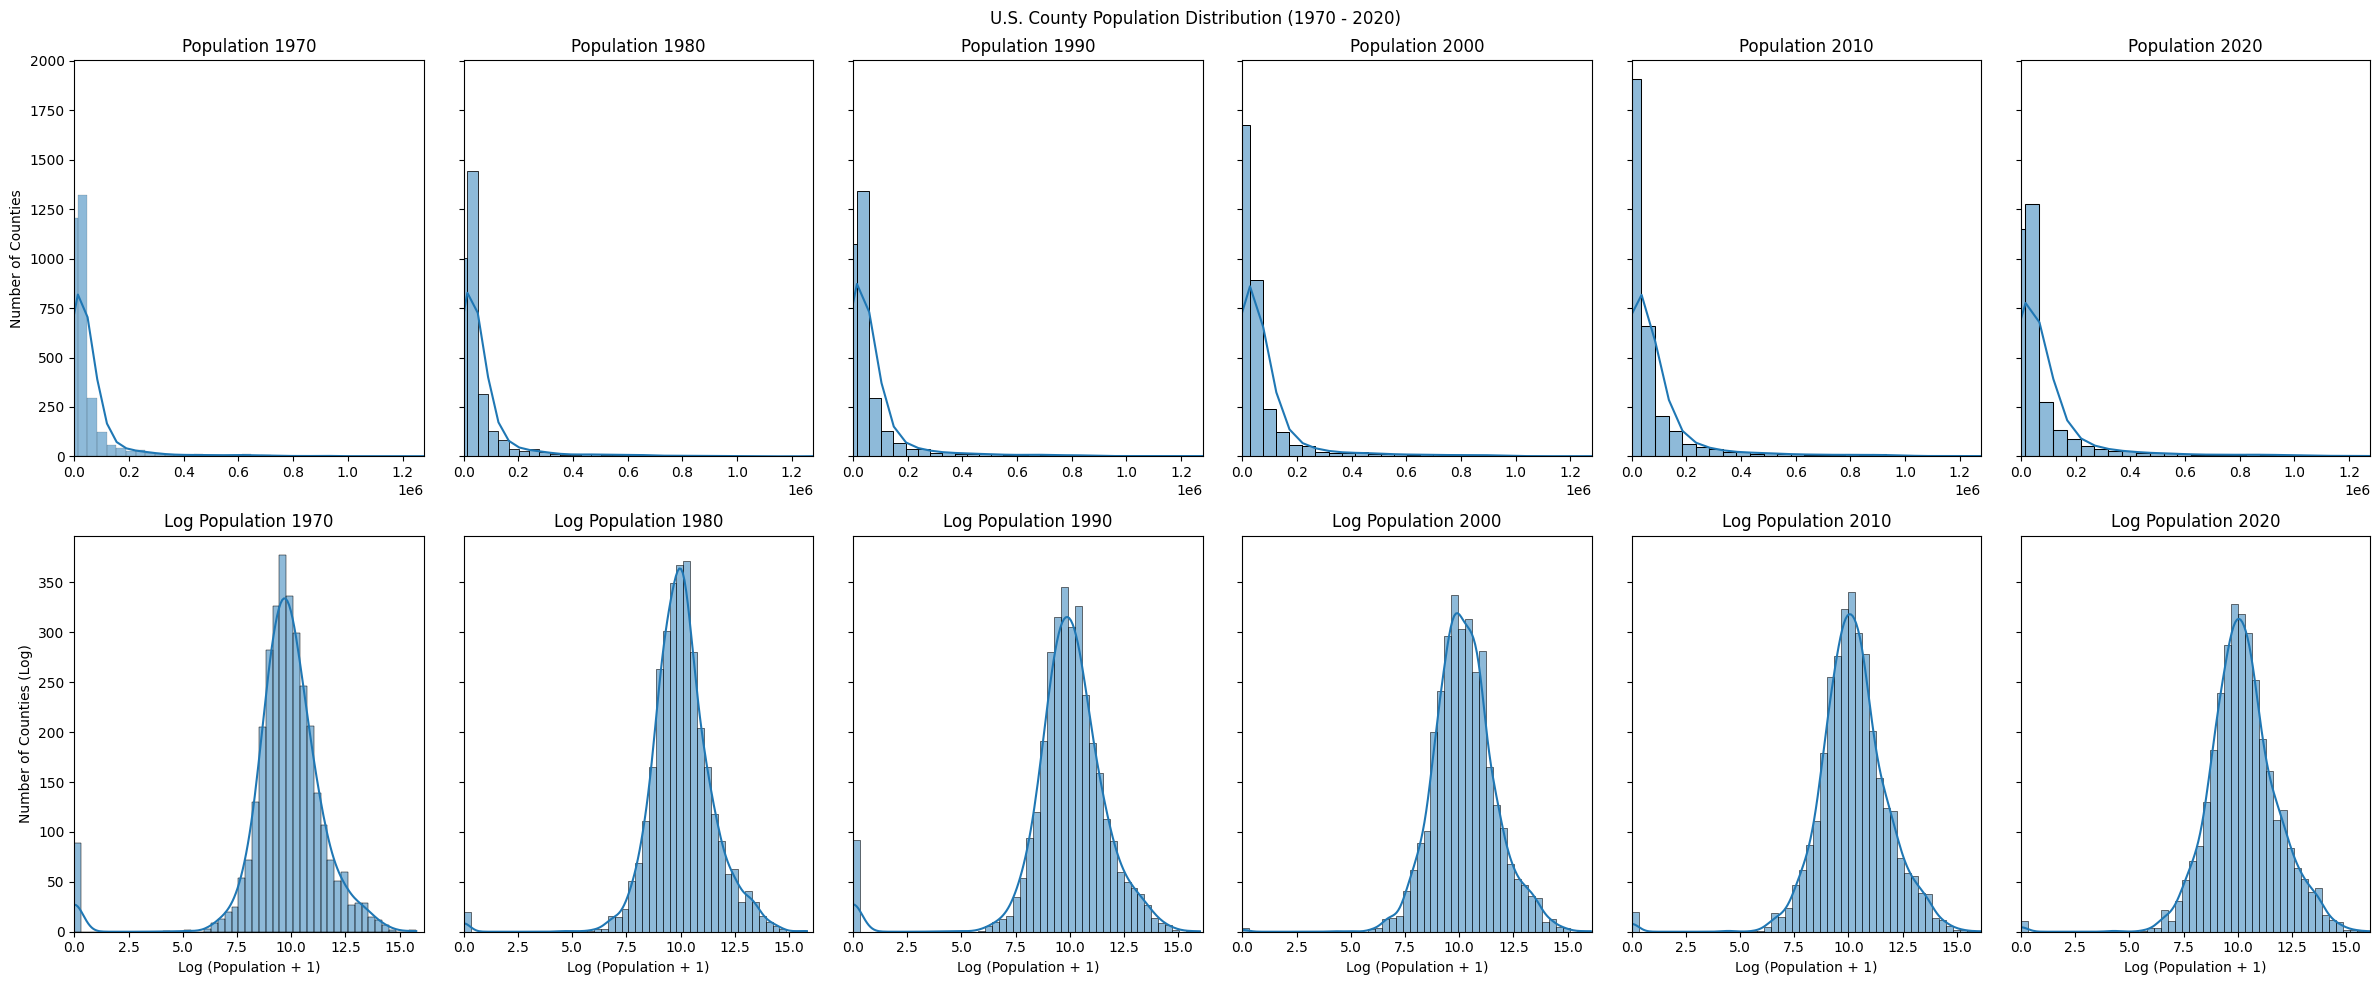

In [ ]:
# Univariate population distributions

years = [1970, 1980, 1990, 2000, 2010, 2020]

fig, axes = plt.subplots(2, 6, figsize=(24,10), sharey='row', sharex='row')

max_pop = census[[f'total_pop_{y}' for y in years]].quantile(0.99).max()
max_log = np.log1p(census[[f'total_pop_{y}' for y in years]].max().max())

for i, year in enumerate(years):
    col_name = f'total_pop_{year}'

    # Row 1: Population (un-scaled)
    sns.histplot(census[col_name], kde=True, ax=axes[0, i], bins=200)
    axes[0, i].set_title(f'Population {year}')
    axes[0, i].set_xlim(0, max_pop)
    axes[0, i].set_xlabel('')

    # Row 2: Population (Log-scaled)
    log_data = np.log1p(census[col_name].clip(lower=0))     # clipping 0 to ignore very small negative flag values
    sns.histplot(log_data, kde=True, ax=axes[1, i], bins=50)
    axes[1, i].set_title(f'Log Population {year}')
    axes[1, i].set_xlim(0, max_log)
    axes[1, i].set_xlabel('Log (Population + 1)')

axes[0, 0].set_ylabel('Number of Counties')
axes[1, 0].set_ylabel('Number of Counties (Log)')
plt.suptitle('U.S. County Population Distribution (1970 - 2020)')
plt.tight_layout()
plt.show()

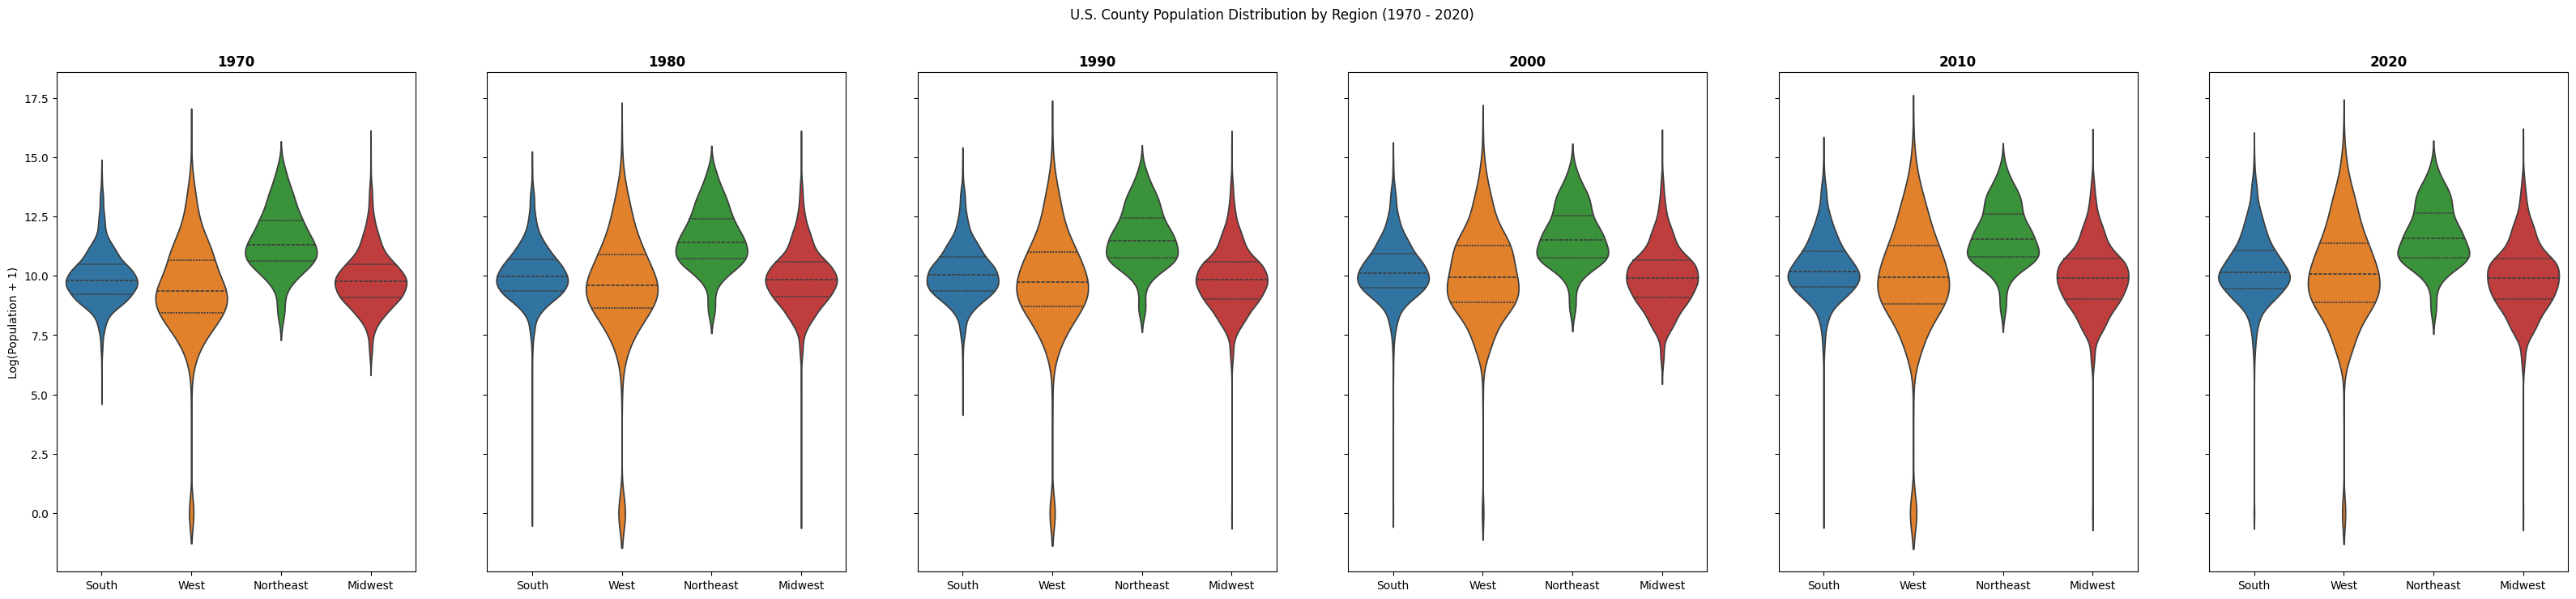

In [ ]:
# Grouped univariate analysis of population distributions

regions = {
    'Northeast': ['Connecticut', 'Maine', 'Massachusetts', 'New Hampshire', 'Rhode Island', 'Vermont', 'New Jersey', 'New York', 'Pennsylvania'],
    'Midwest': ['Illinois', 'Indiana', 'Michigan', 'Ohio', 'Wisconsin', 'Iowa', 'Kansas', 'Minnesota', 'Missouri', 'Nebraska', 'North Dakota', 'South Dakota'],
    'South': ['Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Maryland', 'North Carolina', 'South Carolina', 'Virginia', 'West Virginia', 'Alabama', 'Kentucky', 'Mississippi', 'Tennessee', 'Arkansas', 'Louisiana', 'Oklahoma', 'Texas'],
    'West': ['Arizona', 'Colorado', 'Idaho', 'Montana', 'Nevada', 'New Mexico', 'Utah', 'Wyoming', 'Alaska', 'California', 'Hawaii', 'Oregon', 'Washington']
}

state_to_region = {state: region for region, states in regions.items() for state in states}

census['REGION'] = census['STATE'].map(state_to_region)


fig, axes = plt.subplots(1, 6, figsize=(40,8), sharey=True)

for i, year in enumerate(years):
    col_name = f'total_pop_{year}'

    log_data = np.log1p(census[col_name].clip(lower=0))

    # Population (Log scaled)
    sns.violinplot(census, x='REGION', y=log_data, hue='REGION', ax=axes[i], legend=False, inner="quartile")
    axes[i].set_title(f'{year}', fontweight='bold')
    axes[i].set_xlabel('')

    if i != 0:
        axes[i].set_ylabel('')
    else:
        axes[i].set_ylabel('Log(Population + 1)')

plt.suptitle('U.S. County Population Distribution by Region (1970 - 2020)')
plt.show()

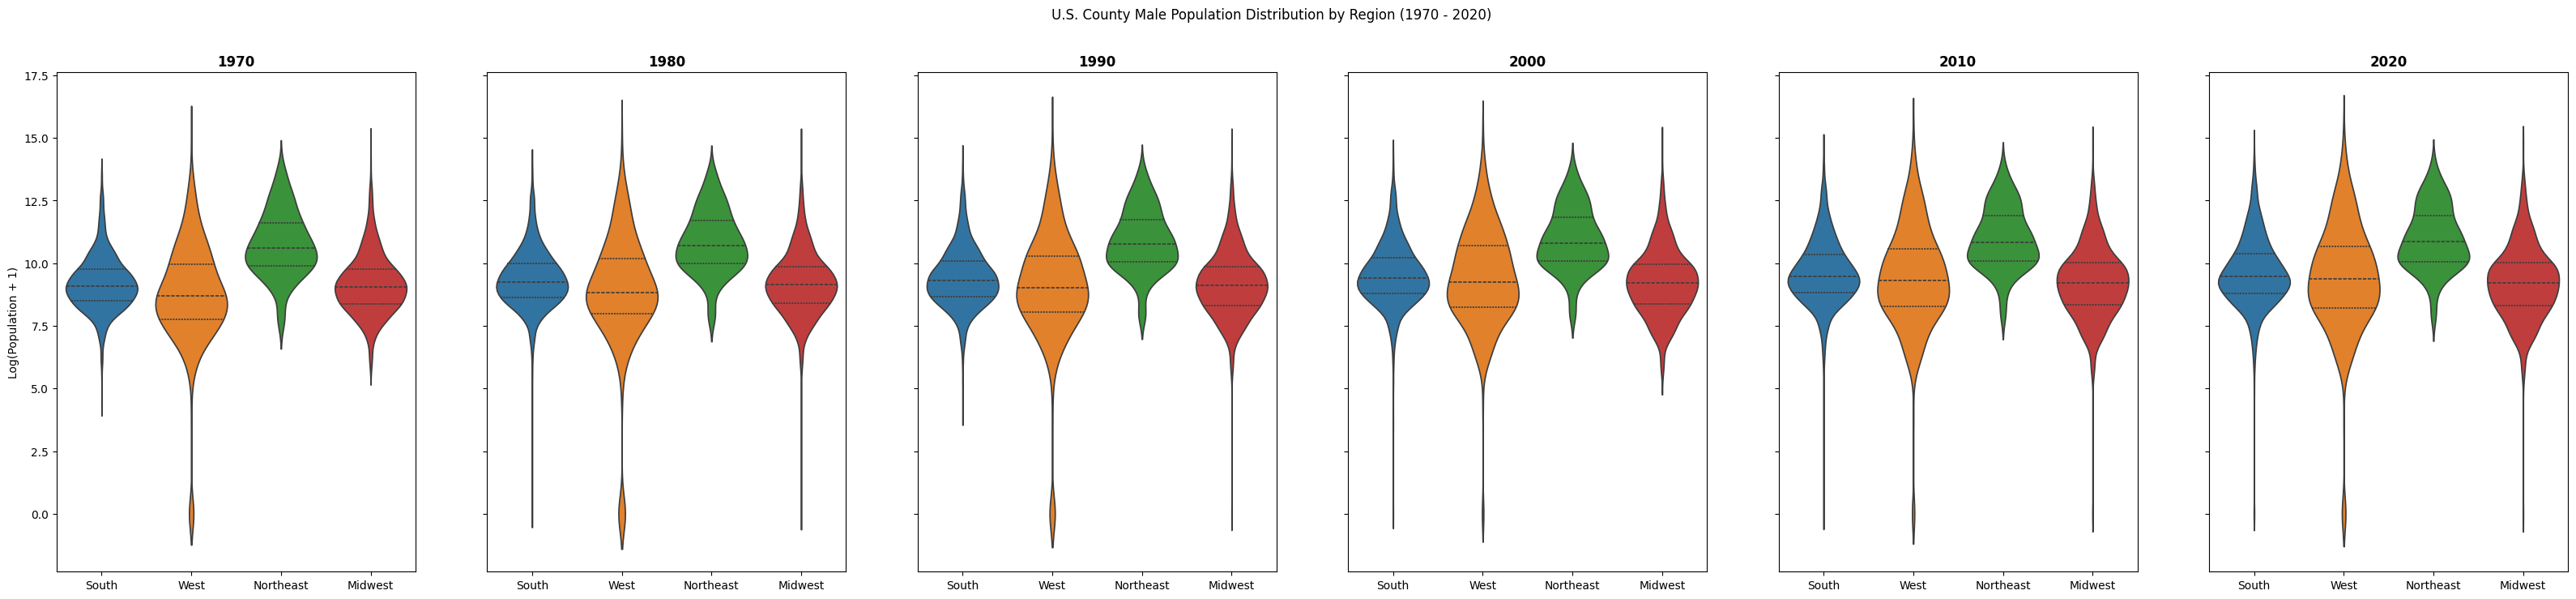

In [ ]:
# Grouped univariate analysis of population distributions

fig, axes = plt.subplots(1, 6, figsize=(40,8), sharey=True)

for i, year in enumerate(years):
    col_name = f'male_pop_{year}'

    log_data = np.log1p(census[col_name].clip(lower=0))

    # Population (Log scaled)
    sns.violinplot(census, x='REGION', y=log_data, hue='REGION', ax=axes[i], legend=False, inner="quartile")
    axes[i].set_title(f'{year}', fontweight='bold')
    axes[i].set_xlabel('')

    if i != 0:
        axes[i].set_ylabel('')
    else:
        axes[i].set_ylabel('Log(Population + 1)')

plt.suptitle('U.S. County Male Population Distribution by Region (1970 - 2020)')
plt.show()

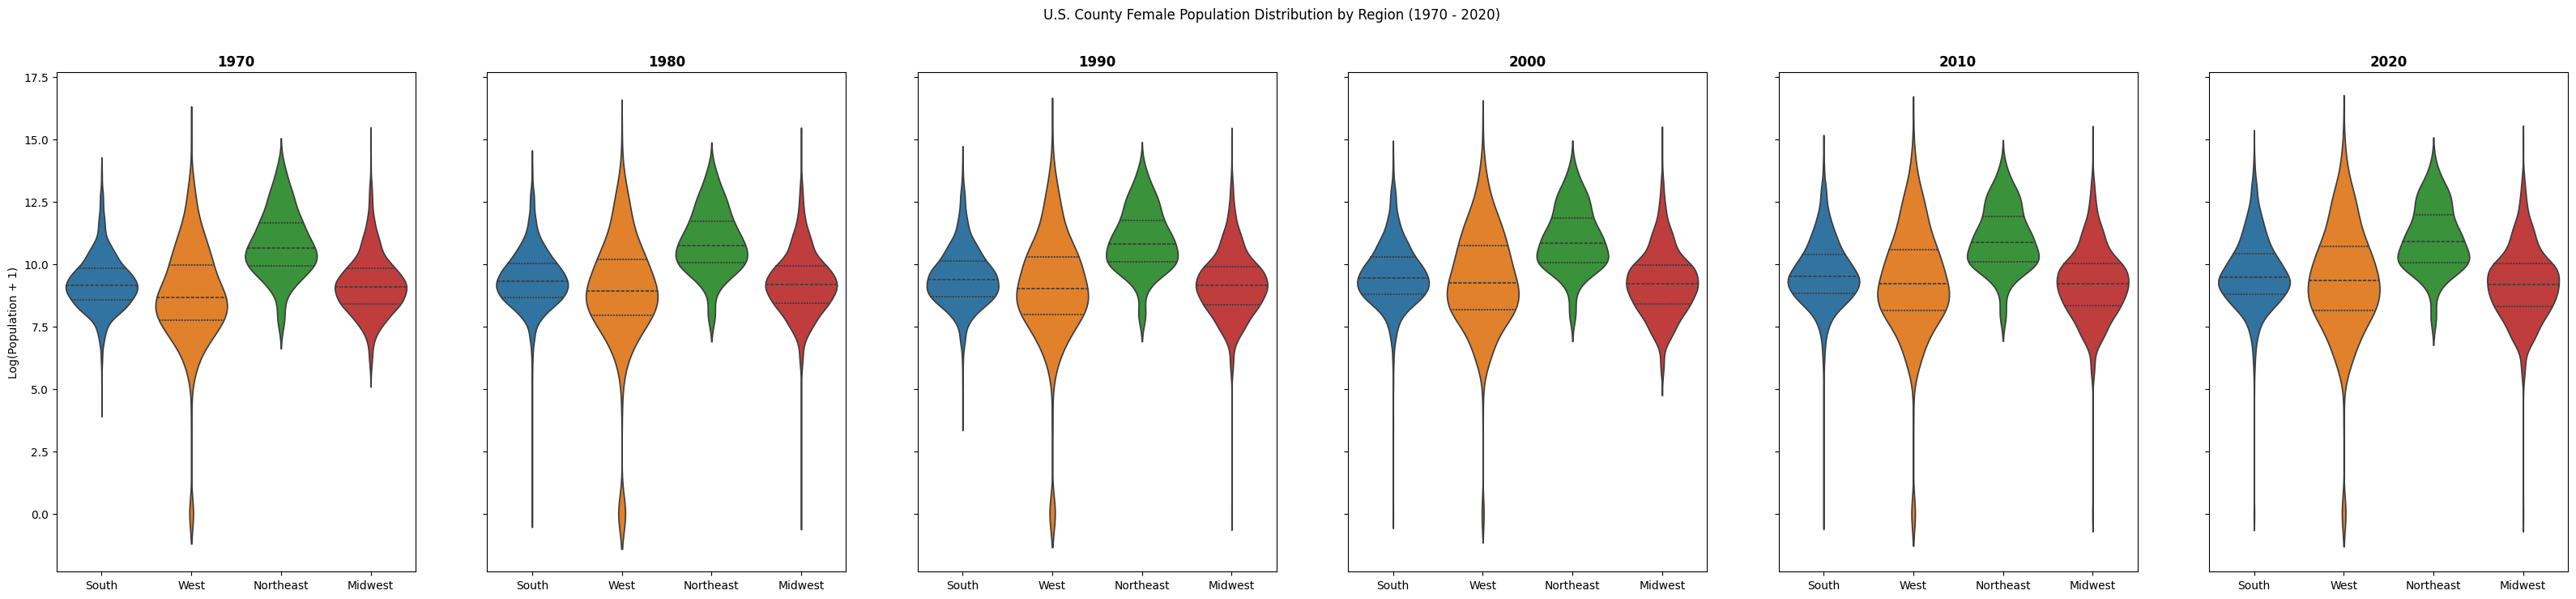

In [ ]:
# Grouped univariate analysis of population distributions

fig, axes = plt.subplots(1, 6, figsize=(40,8), sharey=True)

for i, year in enumerate(years):
    col_name = f'female_pop_{year}'

    log_data = np.log1p(census[col_name].clip(lower=0))

    # Population (Log scaled)
    sns.violinplot(census, x='REGION', y=log_data, hue='REGION', ax=axes[i], legend=False, inner="quartile")
    axes[i].set_title(f'{year}', fontweight='bold')
    axes[i].set_xlabel('')

    if i != 0:
        axes[i].set_ylabel('')
    else:
        axes[i].set_ylabel('Log(Population + 1)')

plt.suptitle('U.S. County Female Population Distribution by Region (1970 - 2020)')
plt.show()

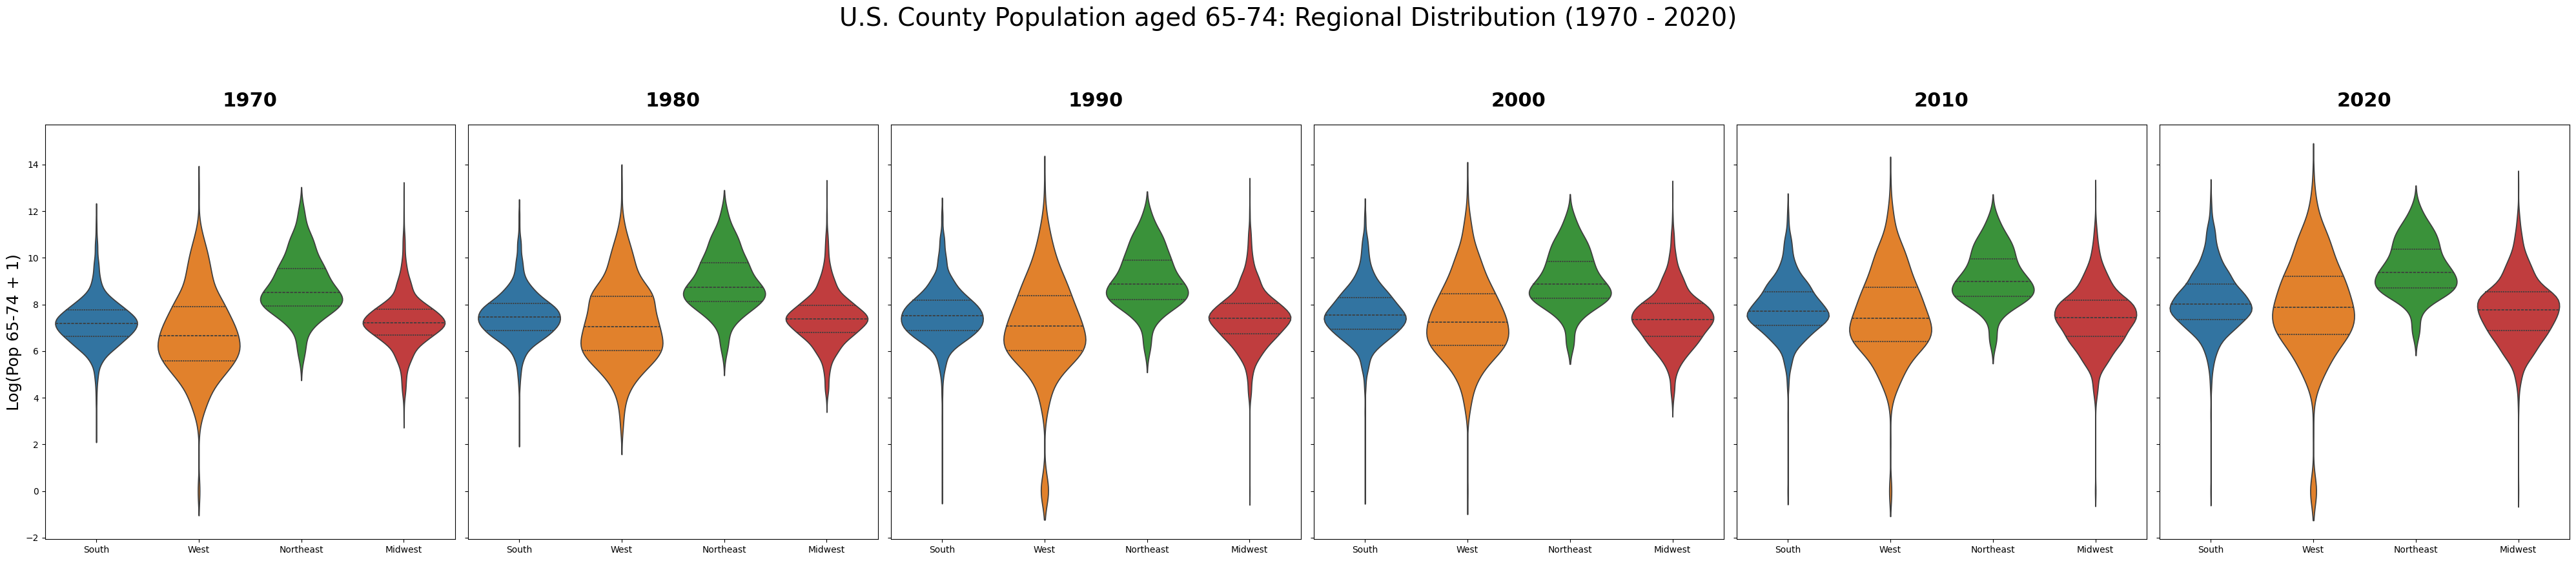

In [ ]:
# Grouped univariate analysis of population distributions

fig, axes = plt.subplots(1, 6, figsize=(40, 8), sharey=True)

region_order = ['South', 'West', 'Northeast', 'Midwest']

for i, year in enumerate(years):
    col_name = f'pop_65_74_years_{year}'
    
    log_data = np.log1p(census[col_name].clip(lower=0))
    
    # 2. Use violinplot to see the distribution shape by region
    sns.violinplot(
        data=census, 
        x='REGION', 
        y=log_data, 
        order=region_order,
        hue='REGION', 
        ax=axes[i], 
        legend=False,
        inner="quartile"
    )
    
    # 3. Titles and clean-up
    axes[i].set_title(f'{year}', fontsize=22, fontweight='bold', pad=20)
    axes[i].set_xlabel('')
    
    # Only show labels on the first plot to prevent "smushing"
    if i != 0:
        axes[i].set_ylabel('')
    else:
        axes[i].set_ylabel('Log(Pop 65-74 + 1)', fontsize=18)


plt.suptitle('U.S. County Population aged 65-74: Regional Distribution (1970 - 2020)', 
             fontsize=28, y=1.08)

plt.tight_layout()
plt.show()

---

## County Cancer Profiles by Sex and Race (2018-2022) - NCI

In [67]:
cancer = pd.read_csv('../Health Disparities Analytics/Processed Data/(COMBINED) Cancer Rates.csv')
cancer.sample(5)

,State,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),Sex,Race,"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
17901,Minnesota,Nicollet,27103,Urban,Male,Asian,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,3,-9999.0,-9999.0,-9999.0,-9999.0
27244,Minnesota,Otter Tail,27111,Rural,Male,NativeAmerican,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,3,-9999.0,-9999.0,-9999.0,-9999.0
1499,Mississippi,Hancock,28045,Urban,Female,Asian,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,3,-9999.0,-9999.0,-9999.0,-9999.0
3381,Illinois,Kendall,17093,Urban,Female,Black,462.5,366.5,575.8,NaN,NaN,NaN,20,-9999.0,-9999.0,-9999.0,-9999.0
3449,Virginia,Greene,51079,Urban,Female,Black,448.6,268.5,705.9,NaN,NaN,NaN,4,-9999.0,-9999.0,-9999.0,-9999.0


In [146]:
cancer['Race'].value_counts()

Race
Asian             6288
Black             6288
Hispanic          6288
NativeAmerican    6288
White             6288
Name: count, dtype: int64

In [147]:
cancer['Sex'].value_counts()

Sex
Female    15720
Male      15720
Name: count, dtype: int64

In [149]:
cancer['2023 Rural-Urban Continuum Codes([rural urban note])'].value_counts()

2023 Rural-Urban Continuum Codes([rural urban note])
Rural    19560
Urban    11870
Name: count, dtype: int64

In [152]:
flag_map = {
    '*': -9999,
    '[P1 note]': -9998,
    '[P3 note]': -9997,
    '[S3 note]': -9996,
    '&para': -9995,

    'rising': -8888,
    'falling': -8887,
    'stable': -8886
}

flag_counts = []

for label, value in flag_map.items():
    count = (cancer == value).sum().sum()
    flag_counts.append({'Flag Label': label, 'Value': value, 'Total Count': count})

results_df = pd.DataFrame(flag_counts)
print(results_df)

  Flag Label  Value  Total Count
0          *  -9999       183420
1  [P1 note]  -9998         8400
2  [P3 note]  -9997           80
3  [S3 note]  -9996         2960
4      &para  -9995            0
5     rising  -8888         1037
6    falling  -8887         1667
7     stable  -8886         8013


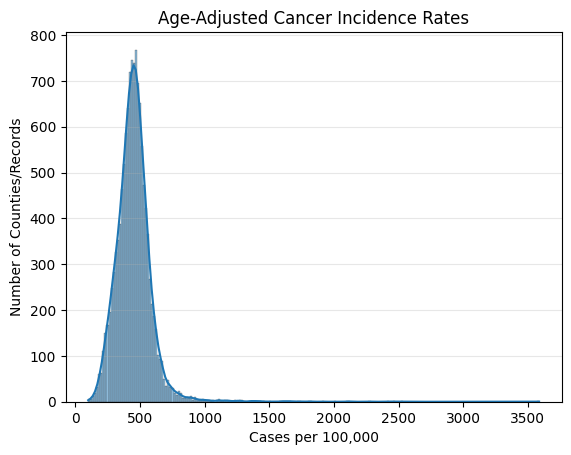

In [ ]:
# True univariate distribution of age-adjusted cancer incidence rates

flags = [-9999, -9998, -9997, -9996, -9995, -8888, -8887, -8886]

target_col = 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'

# get data that is not flagged
plot_df = cancer[~cancer[target_col].isin(flags)] 

sns.histplot(plot_df[target_col], kde=True)
plt.title('Age-Adjusted Cancer Incidence Rates')
plt.xlabel('Cases per 100,000')
plt.ylabel('Number of Counties/Records')
plt.grid(axis='y', alpha=0.3)
plt.show()

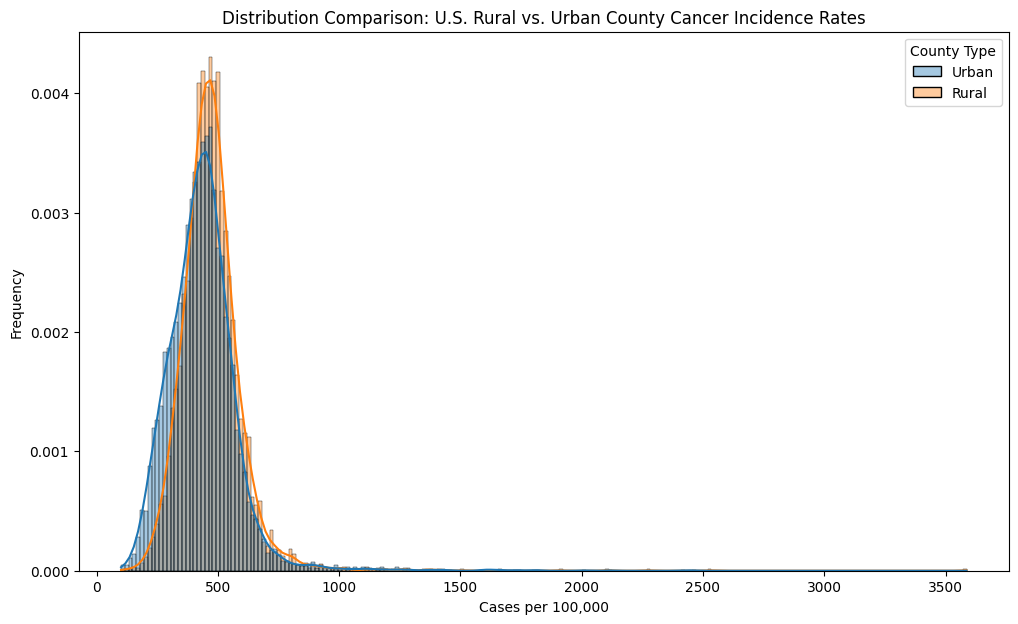

In [ ]:
# Grouped Univariate Analysis of Cancer Incidence Rates


flags = [-9999, -9998, -9997, -9996, -9995, -8888, -8887, -8886]
rural_col = '2023 Rural-Urban Continuum Codes([rural urban note])'
target_col = 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'

# get data that is not flagged
plot_df = cancer[~cancer[target_col].isin(flags)] 

plt.figure(figsize=(12, 7))
ax = sns.histplot(data=plot_df, x=target_col, hue=rural_col, kde=True, alpha=0.4,
                  common_norm=False, stat='density') # removing bias caused by larger proportion of rural samples

plt.title('Distribution Comparison: U.S. Rural vs. Urban County Cancer Incidence Rates')
plt.xlabel('Cases per 100,000')
plt.ylabel('Frequency')
ax.legend_.set_title('County Type')
plt.show()

---

## Life Expectancy at Birth (1900-2018) - NCHS
#### Note: Only data for the following categories: All races, Black, White

In [23]:
life_expect_NCHS = pd.read_csv('../Health Disparities Analytics/Processed Data/NCHS_-_Death_rates_and_life_expectancy_at_birth.csv')
life_expect_NCHS.sample(5)

,Year,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate
842,1909,White,Female,54.2,2092.1
506,1930,Black,Female,49.2,2530.1
287,1949,All Races,Male,65.2,1676.7
350,2012,All Races,Male,76.4,865.1
75,1975,All Races,Both Sexes,72.6,1094.4


In [165]:
life_expect_NCHS.describe()

,Year,Average Life Expectancy (Years),Age-adjusted Death Rate
count,1071.000000,1065.000000,1071.000000
mean,1959.000000,64.500188,1593.061625
std,34.367176,11.843765,682.369379
min,1900.000000,29.100000,611.300000
25%,1929.000000,57.100000,1012.950000
50%,1959.000000,66.800000,1513.700000
75%,1989.000000,73.900000,2057.150000
max,2018.000000,81.400000,3845.700000


In [168]:
life_expect_NCHS[life_expect_NCHS['Average Life Expectancy (Years)'] == 29.1]

,Year,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate
599,1904,Black,Male,29.1,3845.7


In [169]:
life_expect_NCHS[life_expect_NCHS['Average Life Expectancy (Years)'] == 81.4]

,Year,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate
945,2012,White,Female,81.4,623.8
946,2013,White,Female,81.4,623.6
947,2014,White,Female,81.4,617.6


In [171]:
life_expect_NCHS[['Race', 'Sex']].value_counts()

Race       Sex       
All Races  Both Sexes    119
           Female        119
           Male          119
Black      Both Sexes    119
           Female        119
           Male          119
White      Both Sexes    119
           Female        119
           Male          119
Name: count, dtype: int64

Text(0, 0.5, 'Count')

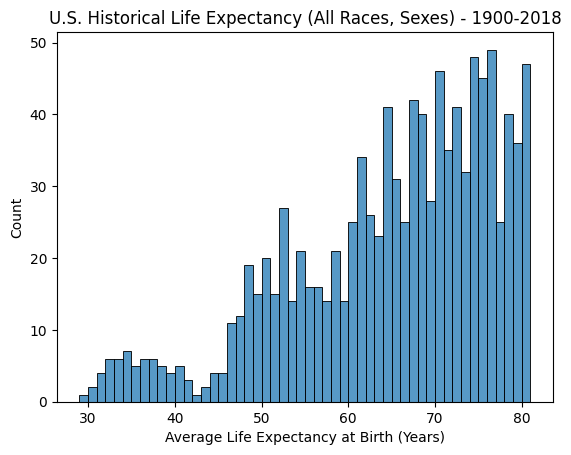

In [187]:
life_expect_NCHS_rounded = pd.DataFrame(life_expect_NCHS['Average Life Expectancy (Years)'].round())

sns.histplot(life_expect_NCHS_rounded, x='Average Life Expectancy (Years)', binwidth=1)
plt.title('U.S. Historical Life Expectancy (All Races, Sexes) - 1900-2018')
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.ylabel('Count')


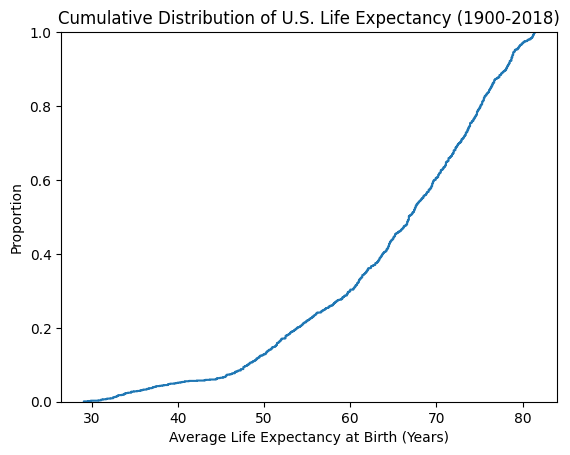

In [186]:
sns.ecdfplot(data=life_expect_NCHS, x='Average Life Expectancy (Years)')
plt.title('Cumulative Distribution of U.S. Life Expectancy (1900-2018)')
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

Text(0, 0.5, 'Count')

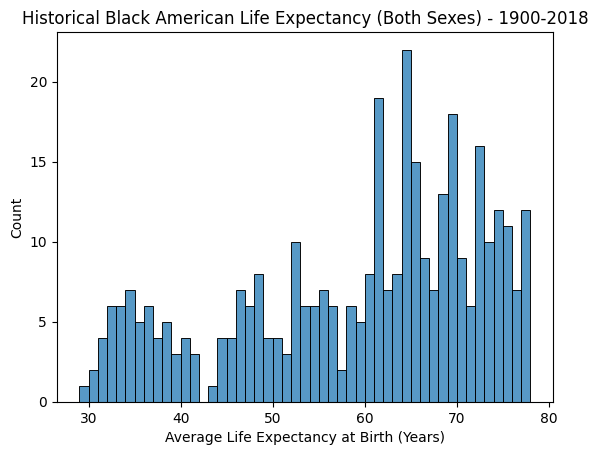

In [189]:
black_americans = life_expect_NCHS[life_expect_NCHS['Race'] == 'Black']
life_expect_NCHS_rounded = pd.DataFrame(black_americans['Average Life Expectancy (Years)'].round())


sns.histplot(life_expect_NCHS_rounded, x='Average Life Expectancy (Years)', binwidth=1)
plt.title('Historical Black American Life Expectancy (Both Sexes) - 1900-2018')
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.ylabel('Count')

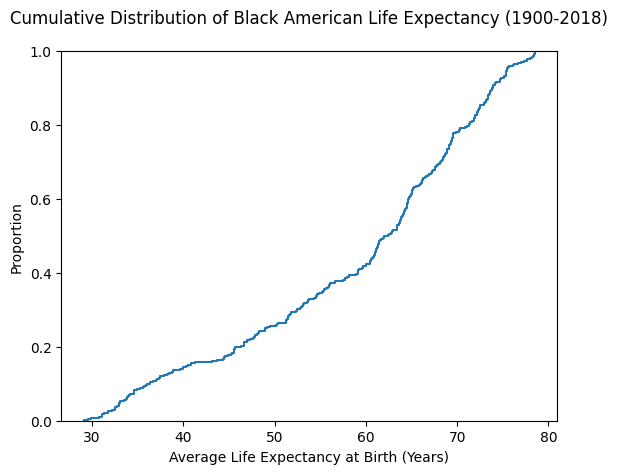

In [193]:
sns.ecdfplot(data=black_americans, x='Average Life Expectancy (Years)')
plt.title('Cumulative Distribution of Black American Life Expectancy (1900-2018)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

Text(0, 0.5, 'Count')

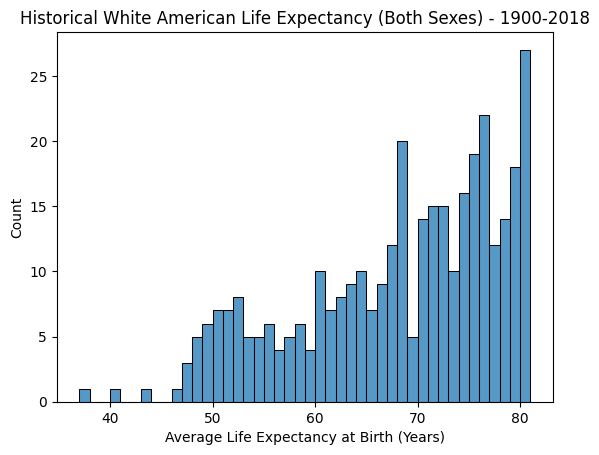

In [195]:
white_americans = life_expect_NCHS[life_expect_NCHS['Race'] == 'White']
life_expect_NCHS_rounded = pd.DataFrame(white_americans['Average Life Expectancy (Years)'].round())


sns.histplot(life_expect_NCHS_rounded, x='Average Life Expectancy (Years)', binwidth=1)
plt.title('Historical White American Life Expectancy (Both Sexes) - 1900-2018')
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.ylabel('Count')

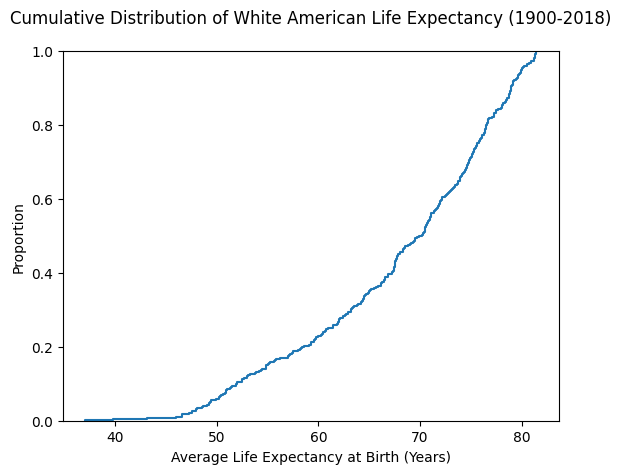

In [196]:
sns.ecdfplot(data=white_americans, x='Average Life Expectancy (Years)')
plt.title('Cumulative Distribution of White American Life Expectancy (1900-2018)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

Text(0, 0.5, 'Count')

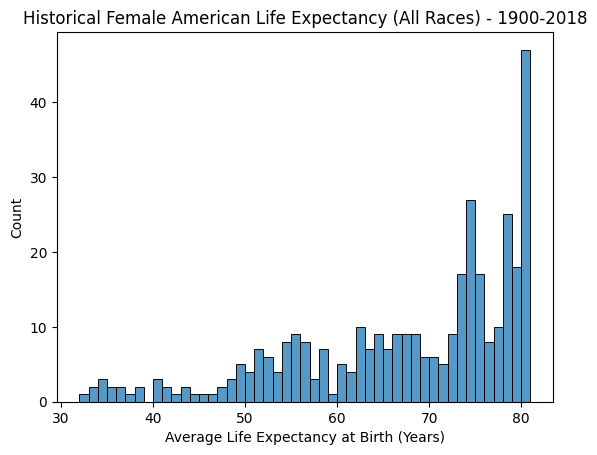

In [197]:
female = life_expect_NCHS[life_expect_NCHS['Sex'] == 'Female']
life_expect_NCHS_rounded = pd.DataFrame(female['Average Life Expectancy (Years)'].round())


sns.histplot(life_expect_NCHS_rounded, x='Average Life Expectancy (Years)', binwidth=1)
plt.title('Historical Female American Life Expectancy (All Races) - 1900-2018')
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.ylabel('Count')

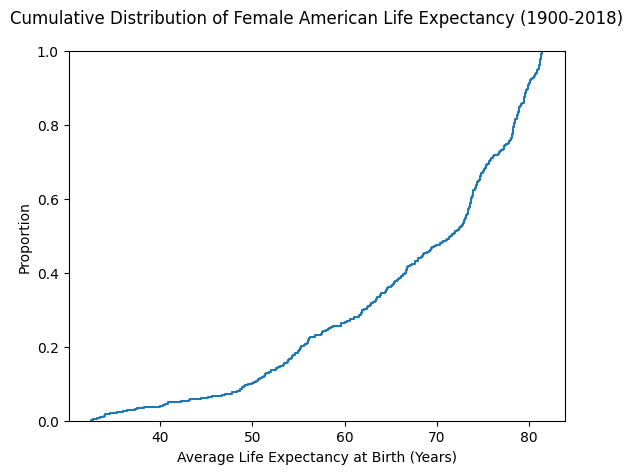

In [198]:
sns.ecdfplot(data=female, x='Average Life Expectancy (Years)')
plt.title('Cumulative Distribution of Female American Life Expectancy (1900-2018)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

Text(0, 0.5, 'Count')

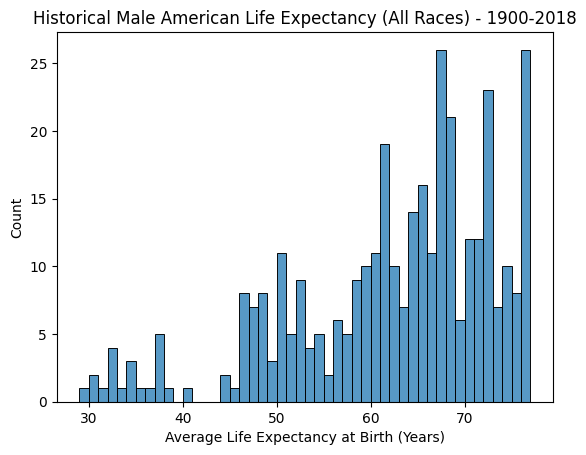

In [199]:
male = life_expect_NCHS[life_expect_NCHS['Sex'] == 'Male']
life_expect_NCHS_rounded = pd.DataFrame(male['Average Life Expectancy (Years)'].round())


sns.histplot(life_expect_NCHS_rounded, x='Average Life Expectancy (Years)', binwidth=1)
plt.title('Historical Male American Life Expectancy (All Races) - 1900-2018')
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.ylabel('Count')

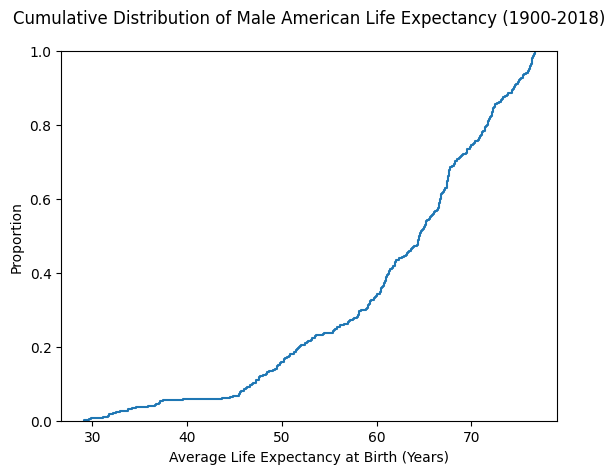

In [200]:
sns.ecdfplot(data=male, x='Average Life Expectancy (Years)')
plt.title('Cumulative Distribution of Male American Life Expectancy (1900-2018)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

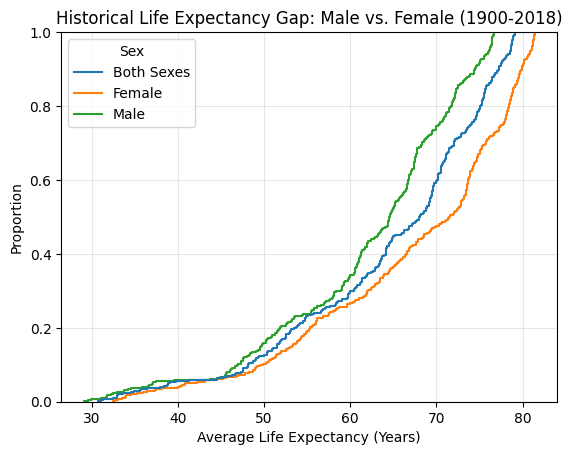

In [202]:
sns.ecdfplot(data=life_expect_NCHS, x='Average Life Expectancy (Years)', hue='Sex')

plt.title('Historical Life Expectancy Gap: Male vs. Female (1900-2018)')
plt.grid(axis='both', alpha=0.3)
plt.show()

---

## Life Expectancy at Birth by Race (2006-2023) - KFF
#### Note: Supplemental dataset for data on a larger set of races

In [69]:
life_expect_KFF = pd.read_csv('../Health Disparities Analytics/Processed Data/KFF - life expectancy at birth by race.csv')
life_expect_KFF.sample(5)

,Year,Overall,White,Black,Hispanic,Asian,AIAN,NHPI
5,2011,78.7,78.7,75.0,81.8,NaN,NaN,NaN
14,2020,77.3,77.6,71.8,78.8,NaN,NaN,NaN
12,2018,78.7,78.6,74.7,81.8,NaN,NaN,NaN
17,2023,78.4,78.4,74.0,81.3,85.2,70.1,NaN
10,2016,78.7,78.6,74.9,81.8,NaN,NaN,NaN


In [13]:
life_expect_KFF.head(18)

,Year,Overall,White,Black,Hispanic,Asian,AIAN,NHPI
0,2006,77.8,78.2,73.1,80.3,NaN,NaN,NaN
1,2007,78.1,78.4,73.5,80.7,NaN,NaN,NaN
2,2008,78.2,78.4,73.9,80.8,NaN,NaN,NaN
3,2009,78.5,78.7,74.4,81.1,NaN,NaN,NaN
4,2010,78.7,78.8,74.7,81.7,NaN,NaN,NaN
5,2011,78.7,78.7,75.0,81.8,NaN,NaN,NaN
6,2012,78.8,78.9,75.1,81.9,NaN,NaN,NaN
7,2013,78.8,78.8,75.1,81.9,NaN,NaN,NaN
8,2014,78.9,78.8,75.3,82.1,NaN,NaN,NaN
9,2015,78.7,78.7,75.1,81.9,NaN,NaN,NaN


In [6]:
life_expect_KFF.describe()

,Year,Overall,White,Black,Hispanic,Asian,AIAN,NHPI
count,18.000000,18.000000,18.000000,18.000000,18.000000,3.000000,3.000000,0.0
mean,2014.500000,78.238889,78.627778,73.950000,80.961111,84.366667,67.733333,NaN
std,5.338539,0.717954,1.320787,1.342189,1.220482,0.850490,2.454248,NaN
min,2006.000000,76.100000,76.400000,70.800000,77.700000,83.500000,65.200000,NaN
25%,2010.250000,77.875000,78.400000,73.200000,80.400000,83.950000,66.550000,NaN
50%,2014.500000,78.550000,78.600000,74.550000,81.500000,84.400000,67.900000,NaN
75%,2018.750000,78.700000,78.775000,74.975000,81.800000,84.800000,69.000000,NaN
max,2023.000000,78.900000,83.300000,75.300000,82.100000,85.200000,70.100000,NaN


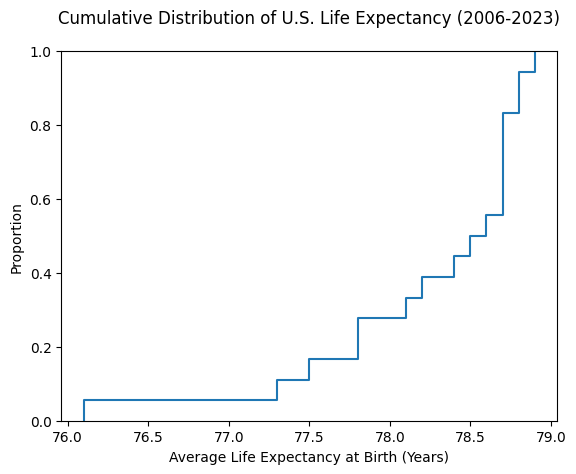

In [7]:
sns.ecdfplot(data=life_expect_KFF, x='Overall')
plt.title('Cumulative Distribution of U.S. Life Expectancy (2006-2023)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

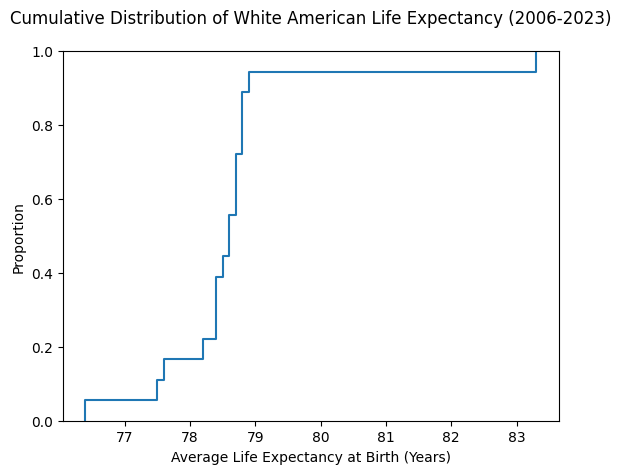

In [8]:
sns.ecdfplot(data=life_expect_KFF, x='White')
plt.title('Cumulative Distribution of White American Life Expectancy (2006-2023)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

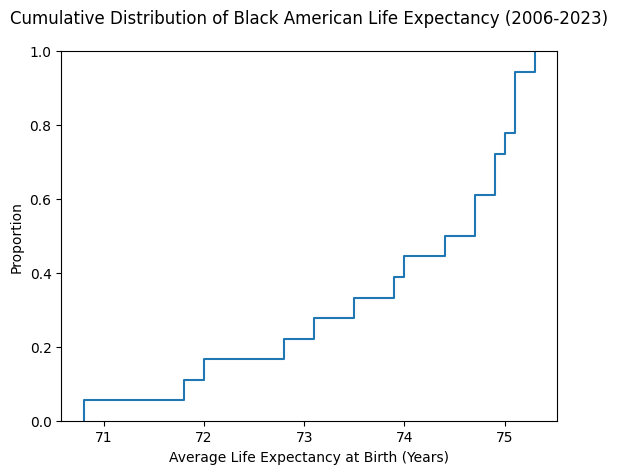

In [9]:
sns.ecdfplot(data=life_expect_KFF, x='Black')
plt.title('Cumulative Distribution of Black American Life Expectancy (2006-2023)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

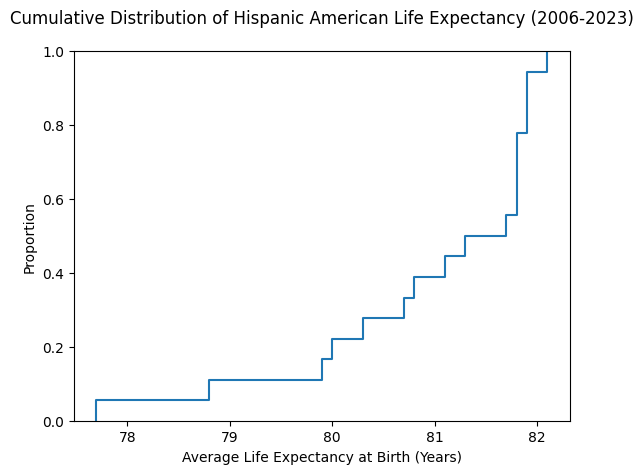

In [ ]:
sns.ecdfplot(data=life_expect_KFF, x='Hispanic')
plt.title('Cumulative Distribution of Hispanic American Life Expectancy (2006-2023)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

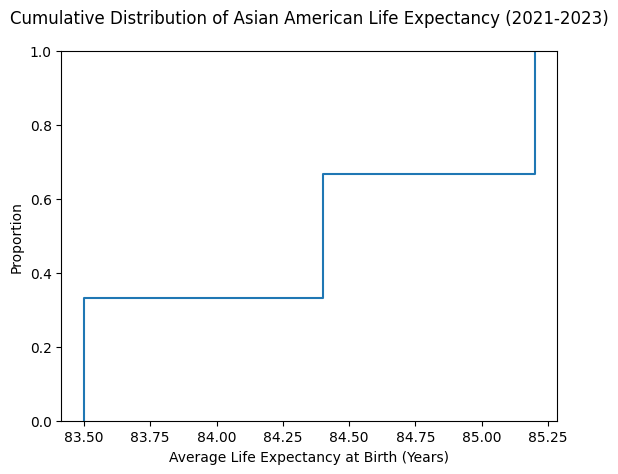

In [14]:
sns.ecdfplot(data=life_expect_KFF, x='Asian')
plt.title('Cumulative Distribution of Asian American Life Expectancy (2021-2023)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

Note: This cumulative distribution is less granular compared to the other cumulative distributions due to the life expectancy numbers only being measured from 2021-2023

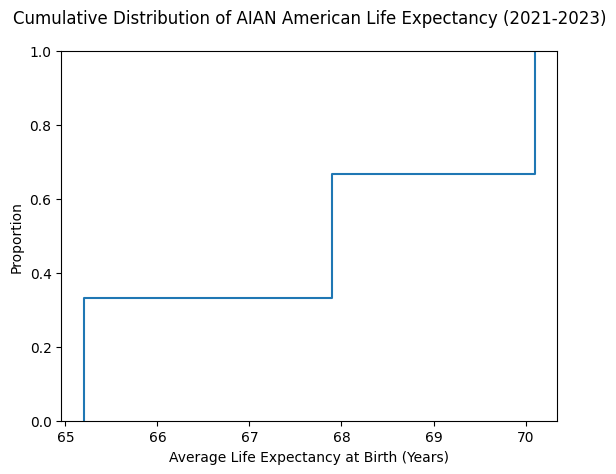

In [15]:
sns.ecdfplot(data=life_expect_KFF, x='AIAN')
plt.title('Cumulative Distribution of AIAN American Life Expectancy (2021-2023)', pad=20)
plt.xlabel('Average Life Expectancy at Birth (Years)')
plt.show()

Note: This cumulative distribution is less granular compared to the other cumulative distributions due to the life expectancy numbers only being measured from 2021-2023

---

## Multiple Mortality Causes (2018-2020) - CDC
#### Note: Data filtered to only cancer mortalities

In [44]:
cancer_mort = pd.read_csv('../Health Disparities Analytics/Processed Data/(COMBINED) cancer_deaths.csv')
cancer_mort.sample(5)

,AGE,SEX,SEX_CODED,RACE,ETHNIC_GROUP,HISPANIC_CODED,MARITAL_STATUS,MARITAL_STATUS_CODED,EDUCATION,EDUCATION_CODED,...,CAUSE_OF_DEATH,CAUSE_RECODE_113,MANNER_OF_DEATH,MANNER_OF_DEATH_CODED,PLACE_OF_DEATH,PLACE_OF_DEATH_CODED,AUTOPSY,DATA_YEAR,MONTH_OF_DEATH,WEEKDAY_OF_DEATH
670834,62.0,Female,F,Black,Non-Hispanic Black,7,Married,M,Less than HS,21,...,"Malignant neoplasms of trachea, bronchus and l...",27,NaN,7.0,Hospice,5,N,2019,9,3
870491,60.0,Female,F,White,Non-Hispanic White,6,Married,M,HS Grad / GED,31,...,"Malignant neoplasms of trachea, bronchus and l...",27,NaN,7.0,Hospital (Inpatient),1,N,2019,10,2
1565881,65.0,Male,M,White,Non-Hispanic White,6,Married,M,HS Grad / GED,31,...,"Malignant neoplasms of colon, rectum and anus ...",23,NaN,7.0,Home,4,N,2020,8,5
1013475,34.0,Female,F,Black,Non-Hispanic Black,7,Never Married,S,Less than HS,21,...,Multiple myeloma and immunoproliferative neopl...,40,NaN,7.0,Hospital (Outpatient/ER),2,N,2019,12,3
1246406,83.0,Male,M,White,Non-Hispanic White,6,Married,M,HS Grad / GED,31,...,"Malignant neoplasms of trachea, bronchus and l...",27,NaN,7.0,Hospital (Inpatient),1,U,2020,2,6


In [45]:
cancer_mort['AGE']

0          93.0
1          61.0
2          63.0
3          67.0
4          76.0
           ... 
1578484    55.0
1578485    71.0
1578486    73.0
1578487    54.0
1578488    70.0
Name: AGE, Length: 1578489, dtype: float64

In [46]:
len(cancer_mort)

1578489

In [47]:
cancer_mort['SEX'].value_counts()

SEX
Male      832272
Female    746217
Name: count, dtype: int64

In [23]:
len(cancer_mort['race_label'].unique())

37

In [49]:
for i in cancer_mort['ETHNIC_GROUP'].unique().tolist():
    print(i)

Non-Hispanic White
AIAN and White
Puerto Rican
American Indian or Alaskan Native (AIAN)
Non-Hispanic Black
Filipino
AIAN and Asian
Samoan
Korean
Mexican
Central or South American
AIAN, Asian and White
Chinese
Japanese
Hawaiian
NHOPI and White
Other/Unknown Hispanic
Cuban
Other or Multiple Pacific Islander
Asian Indian
Asian and White
Vietnamese
Other or Multiple Asian
Black, Asian and White
Guamanian
Asian and NHOPI
Black and White
Asian, NHOPI and White
Black and Native Hawaiian or Other Pacific Islander (NHOPI)
Black, AIAN and White
Black and AIAN
Black and Asian
Black, NHOPI and White
Black, AIAN and Asian
AIAN, NHOPI and White
AIAN, Asian and NHOPI
AIAN, Asian, NHOPI and White
AIAN and NHOPI
Black, Asian and NHOPI
Black, AIAN, Asian and White
Black, AIAN and NHOPI
Black, Asian, NHOPI and White


In [51]:
cancer_mort['ETHNIC_GROUP'].value_counts()

ETHNIC_GROUP
Non-Hispanic White                                             1215063
Non-Hispanic Black                                              187249
Mexican                                                          58489
Other/Unknown Hispanic                                           17215
Central or South American                                        14233
Puerto Rican                                                     13129
Chinese                                                          12428
Cuban                                                             9373
Filipino                                                          9340
American Indian or Alaskan Native (AIAN)                          7911
Other or Multiple Asian                                           5922
Vietnamese                                                        5317
Asian Indian                                                      4961
Korean                                                          

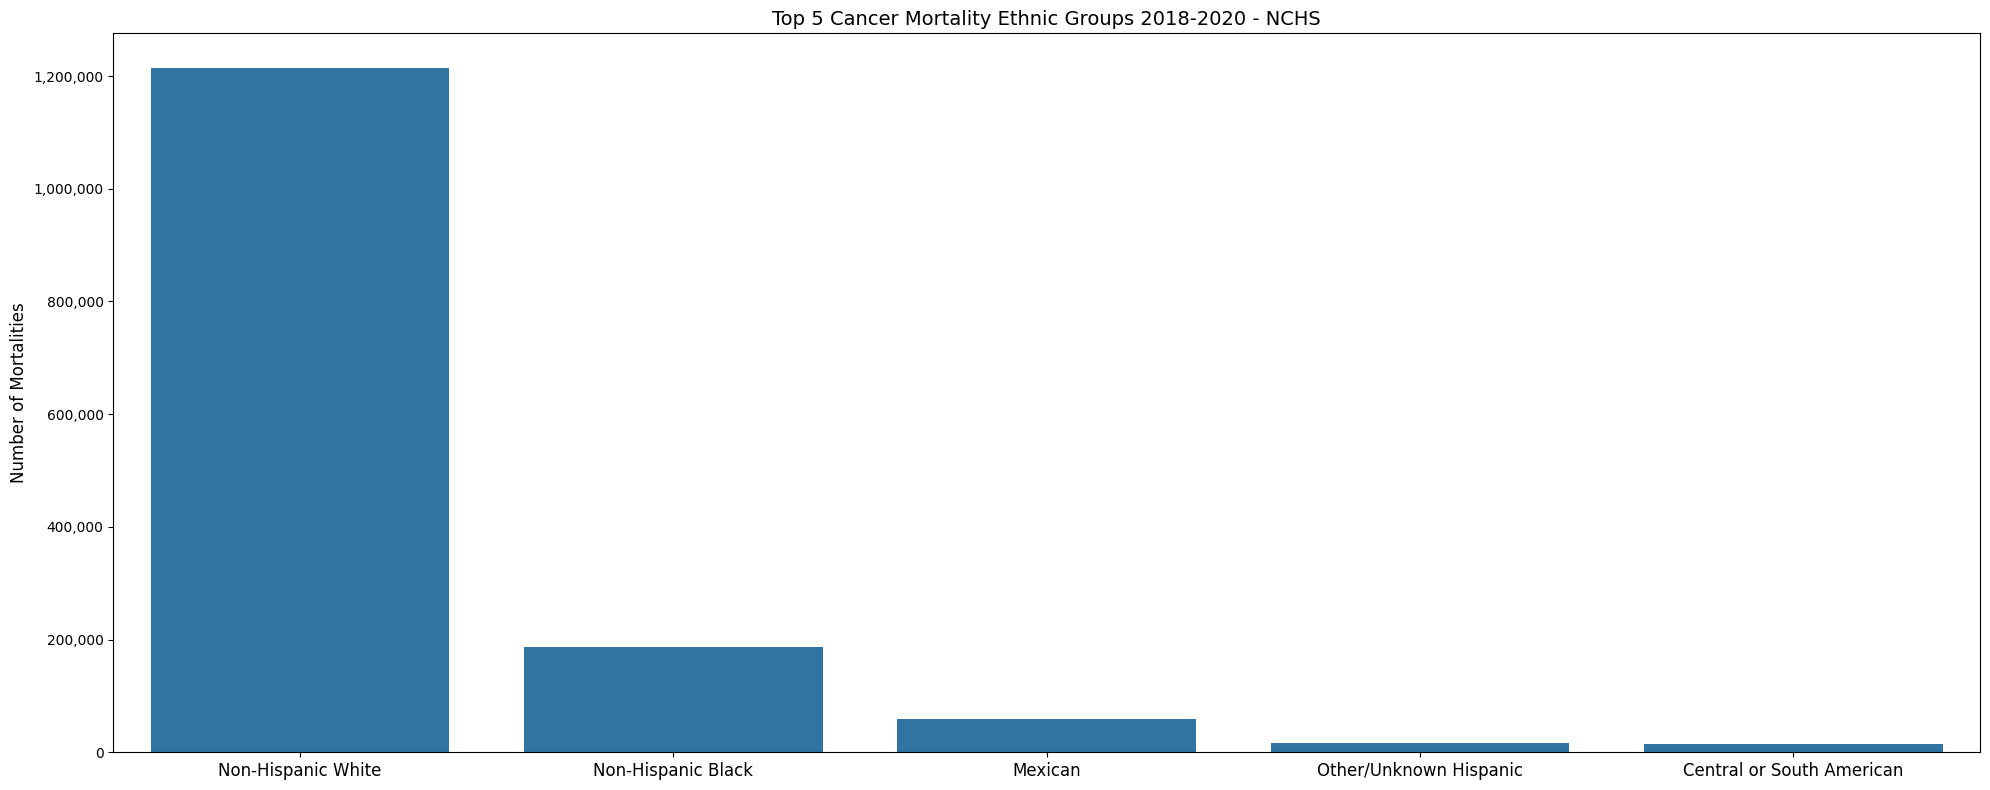

In [75]:
top_5_ethnicities = cancer_mort['ETHNIC_GROUP'].value_counts().head()

plt.figure(figsize=(20,8))
ax = sns.barplot(x=top_5_ethnicities.index, y=top_5_ethnicities.values)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('Top 5 Cancer Mortality Ethnic Groups 2018-2020 - NCHS', fontsize=14)
plt.ylabel('Number of Mortalities', fontsize=12)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.tight_layout()
plt.show()

In [77]:
cancer_mort['EDUCATION'].value_counts()

EDUCATION
HS Grad / GED       652583
Some College        330242
Less than HS        251220
Bachelors Degree    200382
Advanced Degree     123685
Unknown              20377
Name: count, dtype: int64

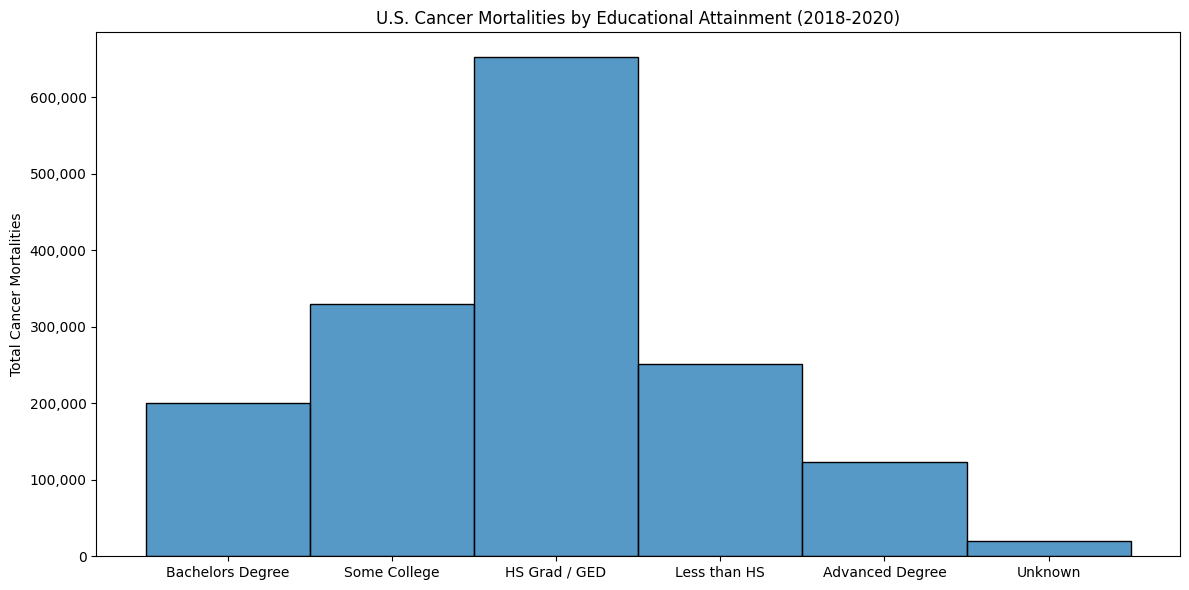

In [83]:
plt.figure(figsize=(12, 6))
ax = sns.histplot(cancer_mort, x='EDUCATION')
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('U.S. Cancer Mortalities by Educational Attainment (2018-2020)')
plt.xlabel('')
plt.ylabel('Total Cancer Mortalities')
plt.tight_layout()
plt.show()

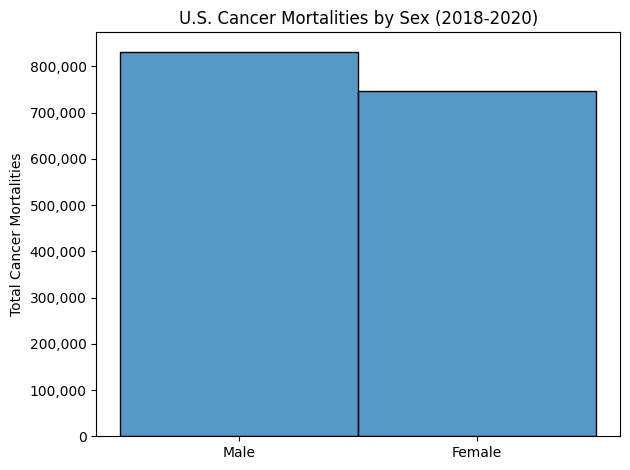

In [84]:
ax = sns.histplot(cancer_mort, x='SEX')
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('U.S. Cancer Mortalities by Sex (2018-2020)')
plt.xlabel('')
plt.ylabel('Total Cancer Mortalities')
plt.tight_layout()
plt.show()

---

## Unemployment and Median Household Income (2000-2023) - ERS

In [8]:
employment_income = pd.read_csv('../Health Disparities Analytics/Processed Data/(IMPUTED) RESHAPED Unemployment and median household income.csv')
employment_income.sample(5)

,FIPS_Code,State,Area_Name,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Metro,Rural_Urban_Continuum_Code,Unemployed,Unemployment_rate,Urban_Influence_Code
21525,19183,IA,"Washington County, IA",2019,12186.0,11892.0,101.2,70539.0,1.0,3.0,294.0,2.412605,2.0
19926,19051,IA,"Davis County, IA",2004,4180.0,3973.0,93.5,65201.0,0.0,9.0,207.0,4.952153,8.0
75745,55117,WI,"Sheboygan County, WI",2013,60745.0,57074.0,91.5,65008.0,1.0,3.0,3671.0,6.043296,2.0
70485,51147,VA,"Prince Edward County, VA",2009,10041.0,9130.0,66.9,57400.0,0.0,6.0,911.0,9.072802,4.0
25611,21113,KY,"Jessamine County, KY",2001,20610.0,19822.0,116.8,69216.0,1.0,2.0,788.0,3.823387,2.0


In [9]:
employment_income.describe()

,FIPS_Code,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Metro,Rural_Urban_Continuum_Code,Unemployed,Unemployment_rate,Urban_Influence_Code
count,78437.000000,78437.000000,7.843700e+04,7.843700e+04,78437.000000,78437.000000,78437.000000,78437.000000,7.843700e+04,78437.000000,78437.000000
mean,31325.010429,2011.497329,1.427576e+05,1.344983e+05,88.861931,62829.710183,0.388057,5.176690,8.259467e+03,5.950349,5.191632
std,16258.622769,6.921850,2.768954e+06,2.609960e+06,20.062794,16593.765479,0.487311,2.942594,1.675163e+05,2.946327,3.501816
min,0.000000,2000.000000,3.800000e+01,3.400000e+01,41.500000,28972.000000,0.000000,1.000000,0.000000e+00,0.000000,1.000000
25%,19023.000000,2005.000000,5.139000e+03,4.812000e+03,75.800000,51934.000000,0.000000,2.000000,2.790000e+02,3.891747,2.000000
50%,30019.000000,2011.000000,1.202800e+04,1.125400e+04,86.900000,60651.000000,0.000000,6.000000,7.140000e+02,5.256306,5.000000
75%,46097.000000,2017.000000,3.290900e+04,3.097700e+04,99.700000,70594.000000,1.000000,8.000000,1.956000e+03,7.255521,8.000000
max,72153.000000,2023.000000,1.666896e+08,1.606237e+08,232.600000,167605.000000,1.000000,9.000000,1.486071e+07,29.409087,12.000000


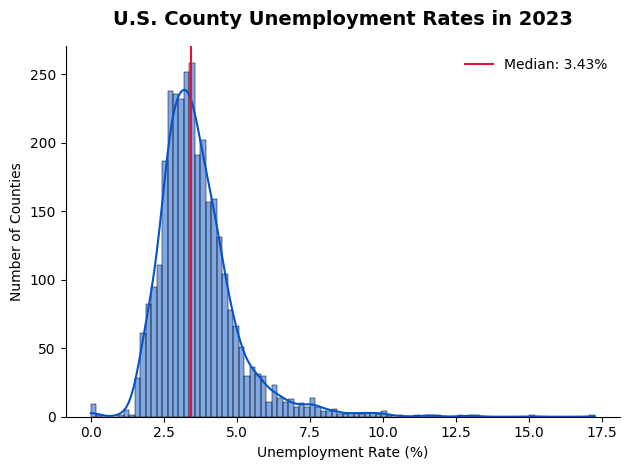

In [62]:
# Ignoring national data - FIPS = 0
# Ignoring state data - FIPS ends in 000
county_unemployment_2023 = employment_income[
    (employment_income['Year'] == 2023) &
    (employment_income['FIPS_Code'] % 1000 != 0)]

sns.histplot(county_unemployment_2023, x='Unemployment_rate', kde=True,
             stat='count', color="#0553c9")


# Using these values to add to the graph to show the distribution compared to the mean/median rates
median_unemp = county_unemployment_2023['Unemployment_rate'].median()

plt.axvline(median_unemp, color='crimson', linestyle='-', label=f'Median: {median_unemp:.2f}%')

plt.title('U.S. County Unemployment Rates in 2023', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Number of Counties')

sns.despine()

plt.legend(frameon=False)
plt.tight_layout()
plt.show()
